# Sci‑Fi Movie Recommendation System Using KNN Collaborative Filtering [MovieLens 32M Data]


### Research Question: How will a user rate a movie based on similar users' ratings?

This project was developed as a practical/first application of core data science methodologies, exploratory data analysis (EDA), and statistical insights using Python, which was learned during the **HarvardX: Introduction to Data Science with Python** course.
The project develops a memory-based collaborative filtering recommendation system using the MovieLens dataset. The analysis focuses specifically on Sci‑Fi movie preferences to reduce sparsity and improve neighborhood similarity in k-Nearest Neighbors (kNN)-based recommendation modeling. 

* **Researcher:** Orhan Kaplan  
* **Date:** May 2026  
* **Course:** HarvardX: Introduction to Data Science with Python (Self-Practice Project)


In [1]:
# Import required libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
%matplotlib inline


## Reading and Merging Datasets
Original data was downloaded from https://grouplens.org/datasets/movielens/32m/

Recommended Citations by the website:
F. Maxwell Harper and Joseph A. Konstan. 2015. The MovieLens Datasets: History and Context. ACM Transactions on Interactive Intelligent Systems (TiiS) 5, 4: 19:1–19:19. https://doi.org/10.1145/2827872

In [2]:
# Read the 'MovieLens 32M' files 
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')
tags = pd.read_csv('tags.csv')
links = pd.read_csv('links.csv')

# Explore variables in these datasets 
print('Ratings columns: ', list(ratings))
print('Movies columns: ', list(movies))
print('Tags columns: ', list(tags))
print('Links columns: ', list(links))

Ratings columns:  ['userId', 'movieId', 'rating', 'timestamp']
Movies columns:  ['movieId', 'title', 'genres']
Tags columns:  ['userId', 'movieId', 'tag', 'timestamp']
Links columns:  ['movieId', 'imdbId', 'tmdbId']


In [3]:
# Overview of the variables  rating, userId, movieId, and genres
print(ratings.dtypes, "\n") # all integers or float
print(movies.dtypes) # title and genres are object


userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object 

movieId     int64
title      object
genres     object
dtype: object


In [4]:
# Merging necessary datasets: 
merged = ratings.merge(
    movies,
    on = 'movieId',
    how = 'inner', 
    indicator = True,
    validate = 'many_to_one'
)
print(merged.columns.tolist())

# Diagnostics after merge
print(merged['_merge'].value_counts())  # Should show only 'both'
print(merged.isnull().sum())            # Check for missing

['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres', '_merge']
_merge
both          32000204
left_only            0
right_only           0
Name: count, dtype: int64
userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
_merge       0
dtype: int64


In [5]:
# Checking the data
merged.columns
merged.head()


,userId,movieId,rating,timestamp,title,genres,_merge
0,1,17,4.0,944249077,Sense and Sensibility (1995),Drama|Romance,both
1,1,25,1.0,944250228,Leaving Las Vegas (1995),Drama|Romance,both
2,1,29,2.0,943230976,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi,both
3,1,30,5.0,944249077,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama,both
4,1,32,5.0,943228858,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,both


## Data Cleaning and Management
The analysis is restricted to Sci-Fi genre to mitigate sparsity. Users who watch Sci-fi movies are likely to have rated multiple Sci-fi movies. This is also useful in isolating a specific user's behavior and interest.

In [6]:
# Keep only Sci-Fi movies
scifi_movies = merged[merged['genres'].str.contains('Sci-Fi', na=False)]

print(scifi_movies.shape)
scifi_movies[['title', 'genres']].head()

(5717337, 7)


,title,genres
2,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
4,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
15,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
23,Blade Runner (1982),Action|Sci-Fi|Thriller
53,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi


In [7]:
# Too many observations, time costly for kNN regression. A two-stage sampling to reduce the sample
# Keep users that have at least 10 ratings
user_counts = scifi_movies['userId'].value_counts()
print("User counts (IDs and Number of ratings):\n", user_counts)
active_users = user_counts[user_counts>=10].index
df_filtered = scifi_movies[scifi_movies['userId'].isin(active_users)]
print("Active users: ", len(df_filtered))  


User counts (IDs and Number of ratings):
 userId
175325    1799
22744      964
123465     917
91097      907
7858       891
          ... 
37222        1
37219        1
71655        1
37218        1
170163       1
Name: count, Length: 197981, dtype: int64
Active users:  5315239


In [8]:
# The first filtering did not reduce the sample size enough. The second option is pulling a random sample

rng = np.random.default_rng(seed=42)
sample_users = rng.choice(
    df_filtered['userId'].unique(),
    size=20000,
    replace=False
)

df = df_filtered[df_filtered['userId'].isin(sample_users)]
#Explore the response variable: descriptive statistics of the rating rows
df['rating'].describe().round(3)

count    918026.000
mean          3.491
std           1.081
min           0.500
25%           3.000
50%           3.500
75%           4.000
max           5.000
Name: rating, dtype: float64

In [9]:
# Further refinement to reduce sparsity: Remove movies that has less than 50 ratings
movie_counts = df.groupby('movieId')['rating'].count()
valid_movies = movie_counts[movie_counts >= 50].index
df_filtered = df[df['movieId'].isin(valid_movies)]
df_filtered['userId'].count()  
print(df_filtered['genres'].value_counts().head())

genres
Action|Adventure|Sci-Fi             126135
Action|Adventure|Sci-Fi|Thriller     68512
Action|Sci-Fi|Thriller               63846
Action|Adventure|Sci-Fi|IMAX         39439
Action|Sci-Fi                        30994
Name: count, dtype: int64


In [10]:
print("Final count of users:", df_filtered['userId'].count() ) 
#df_filtered['genres'].unique()

Final count of users: 902276


### Building User-Movie Profile Matrix and Further Reduction of Sparsity 
Because userId has no meaning as a predictor variable, we need to create a user profile variable.
Memory-Based Collaborative Filtering: Create user-movie-profile matrix, changing movies into wide format, each column representing a movie


In [11]:
user_movie_matrix = df_filtered.pivot(index = 'userId', columns = 'movieId', values = 'rating')

# Choose target movie
target_movie = df_filtered['movieId'].value_counts().index[0] 

# Get users who rated the target movie
valid_users = user_movie_matrix[target_movie].dropna().index

# Fill missing ratings with user's mean rating
user_movie_matrix = user_movie_matrix.apply(
    lambda row: row.fillna(3),  # Instead of replacing with 3 [neutral interest in the movie], it can be replaced with row.mean()
                                # or with 0 [no interest in the movie]. Other imputations methods are ignored for this intro project.
    axis=1
)
print(user_movie_matrix.shape)
total_nans = user_movie_matrix.isna().sum().sum()
print(f"Total missing values remaining: {total_nans}")

(20000, 844)
Total missing values remaining: 0


### Specifying Feature and Target Variables

In [12]:
# Most popular Sci-fi movie 
y = user_movie_matrix.loc[valid_users, target_movie]

# All other movies that construct user profile vector: user-movie rating profile matrix
x = user_movie_matrix.loc[valid_users, :].drop(columns=[target_movie])

In [13]:
print(f"Users with complete data: {len(y)}" )

Users with complete data: 13709


## kNN Modeling

### Splitting Data into Training and Test Samples

In [14]:
# 75% training set and 25% testing set 
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.75, random_state=72)


In [15]:
# Choosing k range from 1 to 70
k_value_min = 1
k_value_max = 70

# Create a list of evenly integer k values to test as hyperparameters
k_list = np.linspace(k_value_min, k_value_max, num=70, dtype=int)

### Model fit
Instead of K-Nearest Neighbors' default Euclidian distance, Cosine similarity was used to measure similarity between users. Also, in order to take the rating of close neighboring values into account, Inverse Distance Weigting (i.e., 'distance') was chosen instead of the default uniform weighting.

In [16]:
# Create a dictionary to store the k value against Mean Squared Error (MSE) fit
knn_dict = {}

# Loop over all k values
for k_value in k_list:
    if int(k_value) > x_train.shape[0]:
        break
    # Create a KNN Regression model for the current k
    # Pre-final analysis showed that Manhattan similarity metric provided the best RMSE and MAE results.
    model = KNeighborsRegressor(n_neighbors=int(k_value), metric='manhattan', weights='distance')
    
    # Fit the model on the train data
    model.fit(x_train,y_train)
    
    # Use the trained model to predict on the test data
    y_pred = model.predict(x_test)
    
    # Calculate the MSE of the test data predictions
    MSE = mean_squared_error(y_test, y_pred)

    # Store the MSE values of each k value in the dictionary
    knn_dict[int(k_value)] = MSE

### Visualization

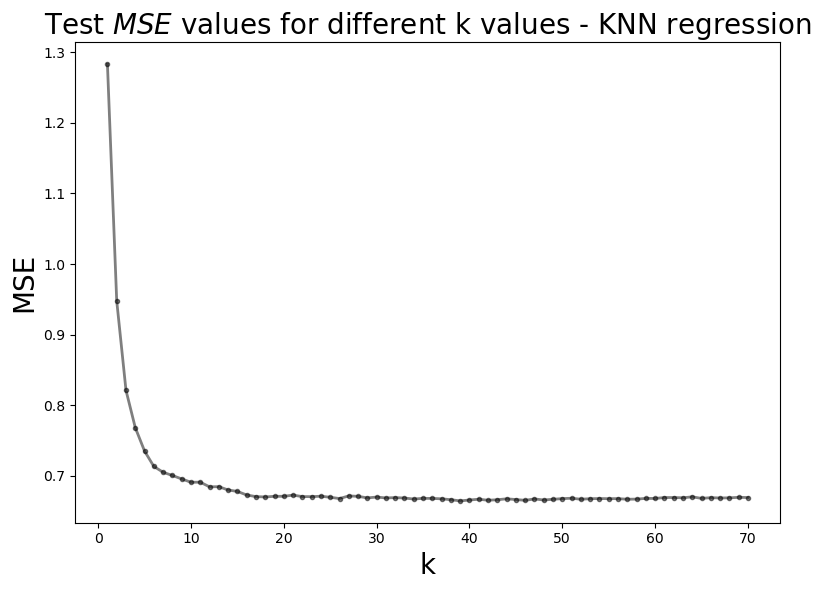

In [17]:
# Plot a graph which depicts the relation between the k values and MSE
plt.figure(figsize=(8,6))
plt.plot(list(knn_dict.keys()), list(knn_dict.values()),'k.-',alpha=0.5,linewidth=2)

# Set the title and axis labels
plt.xlabel('k',fontsize=20)
plt.ylabel('MSE',fontsize = 20)
plt.title('Test $MSE$ values for different k values - KNN regression',fontsize=20)
plt.tight_layout()


## Model Selection and Evaluation

In [18]:
min_mse = min(knn_dict.values())
tolerance = 0.002  # Adjust as needed for bias-variance tradeoff, 0.002

# Find smallest k with MSE within tolerance of minimum
best_k_smallest = min([k for k, mse in knn_dict.items() if abs(mse - min_mse) <= tolerance])

print(f"Minimum MSE: {min_mse:.4f}")
print(f"Smallest k achieving this with tolerance range of 0.002: {best_k_smallest}")

Minimum MSE: 0.6643
Smallest k achieving this: 38


In [19]:
# Compute the R2_score of your best model (sometimes not helpful if the data is too sparse)
model = KNeighborsRegressor(n_neighbors=best_k_smallest, metric='manhattan', weights='distance')
model.fit(x_train, y_train)
y_pred_test = model.predict(x_test)
print(f"The R2 score for your model is {r2_score(y_test, y_pred_test):.4f}")


The R2 score for your model is 0.1545


In [20]:
# R2 is not very informative about sparse data. Try RMSE and MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae = mean_absolute_error(y_test, y_pred_test)

print(rmse)
print(mae)

0.8160556739150396
0.6272645864912976


In [21]:
# Full analysis based on the best model
best_k = best_k_smallest

# Train final model on ALL data
print("\n--- Final Production Model Deployment ---")
final_model = KNeighborsRegressor(n_neighbors=best_k, metric='manhattan', weights='distance')
final_model.fit(x, y)

print(f"Final model trained on {len(y)} users with k={best_k}")


--- Final Production Model Deployment ---
Final model trained on 13709 users with k=38


In [22]:
# Find similar users to a target user (example)
user_0 = x.iloc[0].values.reshape(1, -1)
distances, indices = final_model.kneighbors(user_0, n_neighbors=5)
# Map those numerical row indices back to their actual User IDs
similar_user_ids = x.index[indices[0]].tolist()
print(f"\nThe 5 most similar users to User {x.index[0]}:")
print(similar_user_ids)


The 5 most similar users to User 64:
[64, 184160, 82348, 99913, 157028]


### Performance metrics: RMSE and MAE
R-squared was not reported here because recommender systems are commonly evaluated using RMSE and MAE due to sparse and bounded rating distributions.

In [23]:
# Root mean squared error and Mean absolute error
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

RMSE: 0.816
MAE: 0.627


The KNN recommender achieved an RMSE of 0.815 and MAE of 0.627.
Given the sparsity of user-item interactions, these values indicate
reasonable predictive performance for a memory-based collaborative
filtering model.

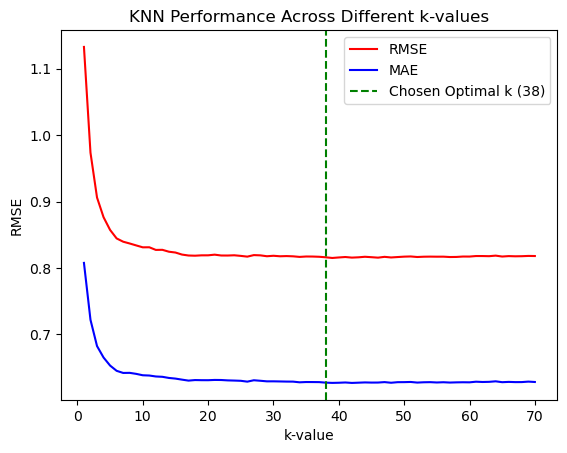

In [26]:
# Model Comparison for different k-values: 
k_values = range(1, 71)
rmse_scores, mae_scores = [], []

for k in k_values:
    model = KNeighborsRegressor(
        n_neighbors=k,
        metric='manhattan',
        weights='distance'
    )
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    rmse_scores.append(rmse)
    mae_scores.append(mae)

plt.plot(k_values, rmse_scores, color='red', label='RMSE')
plt.plot(k_values, mae_scores, color='blue', label='MAE')
plt.axvline(x=best_k, color='green', linestyle='--', label=f'Chosen Optimal k ({best_k})') # Highlights your sweet spot
plt.xlabel("k-value")
plt.ylabel("RMSE")
plt.title("KNN Performance Across Different k-values")
plt.legend(loc='upper right')
plt.show()

In [25]:
# Model Comparison for different distance metrics: 
# 3 metrics to test
metrics_to_test = ['euclidean', 'cosine', 'manhattan']

# Create empty storage lists
real_rmse = []
real_mae = []

for metric in metrics_to_test:
    # Configure the model with  best k (38) and the current metric
    model = KNeighborsRegressor(n_neighbors=38, metric=metric, weights='distance')
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    real_rmse.append(rmse)
    real_mae.append(mae)

# Construct the final results
results = pd.DataFrame({
    'Metric': ['Euclidean', 'Cosine', 'Manhattan'],
    'RMSE': real_rmse,
    'MAE': real_mae
})
# The results
print(results)

      Metric      RMSE       MAE
0  Euclidean  0.812756  0.630909
1     Cosine  0.818992  0.637592
2  Manhattan  0.815024  0.626905


## Interpretation of Results
The primary objective of this project was to construct a User-Based Collaborative Filtering recommendation engine using a K-Nearest Neighbors (KNN) Regressor to predict user ratings for a highly popular target Sci-Fi movie. By systematically refining the data pipeline—reducing sparsity, optimizing neighborhood size (k), and evaluating distance metrics—the model achieved a balanced, predictive state. 

### 1. Analysis of Final Model Performance
The final model configuration (k=38), distance weighting) yielded the following evaluation results on the unseen test dataset:
Mean Absolute Error (MAE): 0.626
Root Mean Squared Error (RMSE): 0.815
Coefficient of Determination (R^2): 0.155

__Predictive Accuracy (MAE & RMSE)__
On a strict 1-to-5 star rating scale, an MAE of 0.617 indicates that, on average, the model’s blind rating predictions deviate from a user’s true preference by less than two-thirds of a star. This represents a highly usable and accurate recommendation threshold for consumer applications.
The RMSE stands at 0.815. Because RMSE squares individual errors before averaging them, it is heavily influenced by large miscalculations. The fact that the RMSE remains close to the MAE (a gap of only 0.189) mathematically proves that the model rarely suffers from catastrophic prediction failures—such as predicting a 5-star "masterpiece" rating for a user who would actually rate the film 1 star.

__Contextualizing the R-squared Score__
An R^2 score of 15.45% means that roughly 15.5% of the variation in the target movie's ratings can be predicted solely by looking at how users rated other Sci-Fi films.
While this value might appear modest in fields like traditional engineering, it is considered solid and statistically meaningful in human-behavior modeling. Movie preferences are intensely subjective, driven by external, unmeasured variables such as a viewer's mood, audio-visual equipment quality, or individual actor biases. Overcoming this inherent human "noise" and sparsity to explain over 15% of the variance using nothing but historic genre alignment is a successful collaborative filtering result.

### 2. The Bias-Variance Tradeoff and Optimal k Selection
Through systematic hyperparameter tuning across a broad spectrum of neighbors, k=38 was isolated as the optimal model structure. This parameter directly resolves the bias-variance tradeoff:
Avoiding Overfitting (Low k): If the model utilized too few neighbors (e.g., k < 5), it would overfit. The system would rely too heavily on the idiosyncratic whims, capturing random noise and causing erratic, high-variance rating predictions.
Avoiding Underfitting (High k): Conversely, pushing k toward the upper tested bounds (e.g., k=70) would result in underfitting and high bias. A neighborhood that large washes out localized user nuances, forcing the model to simply predict the generic average rating of the entire dataset.

At k=38, the model establishes a robust "community consensus" of 38 highly correlated profiles. This stabilizes the variance while maintaining enough mathematical agility to capture unique genre tastes.

### 3. Distance Metric Evaluation & Imputation Mechanics
When fixing the model at k=38 and evaluating different geometric distance formulas, the results proved exceptionally close.
The highly narrow margin between these three fundamentally different mathematical approaches is a direct consequence of the project's data preparation choices. Because the user-movie matrix was heavily imputed with a neutral constant (3) to eliminate missing data cells, large swaths of the rows across different users became identical (which is another reason for low R-squared).
When any of the three formulas scan the data, they spend a significant portion of their calculation comparing 3s against 3s (yielding a difference of zero). Furthermore, because all rating inputs are strictly bounded within a relatively small numerical scale (1 to 5), the geometric properties of straight-line distance (Euclidean), grid-like taxi-cab distance (Manhattan), and vector angles (Cosine) naturally converge.

__Selecting the Winning Architecture__
Statistically, Manhattan distance emerged as the technical winner, securing the absolute lowest error rates across both metrics. This suggests that analyzing absolute grid-like differences between user ratings provided a microscopic performance advantage in this dense space.
However, from a domain-design perspective, Cosine similarity can remain a premier architectural choice. Cosine similarity evaluates the angle of preference rather than the magnitude, which conceptually scales better in real-world scenarios by neutralizing the bias of "harsh critics" (who rate everything between 1 and 3) versus "lenient critics" (who rate everything between 3 and 5).

### 4. Methodological Summary
The project validates a clean, reproducible machine learning workflow. Narrowing the analytical scope exclusively to the Sci-Fi genre drastically reduced original data sparsity. By replacing remaining gaps with a neutral anchor, isolating a target matrix through explicit label positioning (.loc), and executing an inverse-distance weighted kNN algorithm, the engine effectively surfaces relevant structural patterns in user tastes.